In [1]:
# !rm -rf '/content/DIS_Hughen'
# !git clone https://github.com/NU-Academics/DIS_Hughen.git

In [2]:
import numpy as np
import pandas as pd
import shap
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import  accuracy_score, classification_report, confusion_matrix, f1_score, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from torch.utils.data import TensorDataset, DataLoader

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cpu


In [4]:
df = pd.read_csv("undersampled_CIC2019_dataset.csv")
# df = pd.read_csv("/content/DIS_Hughen/undersampled_CIC2019_dataset.csv")

In [5]:
df.shape

(4685611, 90)

In [6]:
attack_set = df[df["label"] != "BENIGN"]
attack_sample = (attack_set.groupby("label", group_keys=False).sample(n=2000, random_state=42, replace=True).reset_index(drop=True))

In [7]:
attack_sample.shape

(36000, 90)

In [8]:
print(attack_sample["label"].value_counts())

label
DrDoS_DNS        2000
DrDoS_LDAP       2000
DrDoS_MSSQL      2000
DrDoS_NTP        2000
DrDoS_NetBIOS    2000
DrDoS_SNMP       2000
DrDoS_SSDP       2000
DrDoS_UDP        2000
LDAP             2000
MSSQL            2000
NetBIOS          2000
Portmap          2000
Syn              2000
TFTP             2000
UDP              2000
UDP-lag          2000
UDPLag           2000
WebDDoS          2000
Name: count, dtype: int64


In [9]:
benign_set = df[df["label"] == "BENIGN"]
benign_sample = benign_set.sample(n=attack_sample.shape[0], replace=True, random_state=42)

In [10]:
benign_sample.shape

(36000, 90)

In [11]:
print(benign_sample["label"].value_counts())

label
BENIGN    36000
Name: count, dtype: int64


In [12]:
df_sample =pd.concat([benign_sample, attack_sample]).reset_index(drop=True)

In [13]:
df_sample.shape

(72000, 90)

In [14]:
print(df_sample["label"].value_counts())

label
BENIGN           36000
DrDoS_DNS         2000
DrDoS_LDAP        2000
DrDoS_MSSQL       2000
DrDoS_NTP         2000
DrDoS_NetBIOS     2000
DrDoS_SNMP        2000
DrDoS_SSDP        2000
DrDoS_UDP         2000
LDAP              2000
MSSQL             2000
NetBIOS           2000
Portmap           2000
Syn               2000
TFTP              2000
UDP               2000
UDP-lag           2000
UDPLag            2000
WebDDoS           2000
Name: count, dtype: int64


In [15]:
le = LabelEncoder()
df_sample["label"] = le.fit_transform(df_sample["label"])
X = df_sample.drop(columns=["label"], errors="ignore").select_dtypes(include=[np.number])
X.replace([np.inf, -np.inf], np.nan, inplace=True)
X.fillna(0, inplace=True)
y = df_sample["label"]
label_mapping = dict(zip(le.classes_, range(len(le.classes_))))
print(label_mapping)

{'BENIGN': 0, 'DrDoS_DNS': 1, 'DrDoS_LDAP': 2, 'DrDoS_MSSQL': 3, 'DrDoS_NTP': 4, 'DrDoS_NetBIOS': 5, 'DrDoS_SNMP': 6, 'DrDoS_SSDP': 7, 'DrDoS_UDP': 8, 'LDAP': 9, 'MSSQL': 10, 'NetBIOS': 11, 'Portmap': 12, 'Syn': 13, 'TFTP': 14, 'UDP': 15, 'UDP-lag': 16, 'UDPLag': 17, 'WebDDoS': 18}


In [16]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [17]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)

In [18]:
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.long)

X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val.values, dtype=torch.long)

train_loader = DataLoader(TensorDataset(X_train_tensor, y_train_tensor), batch_size=128, shuffle=True)
val_loader = DataLoader(TensorDataset(X_val_tensor, y_val_tensor), batch_size=128)

In [19]:
input_size = 88
hidden_size = 64
num_classes = 19

class MultiClassDNN(nn.Module):
    def __init__(self, input_size=88, num_classes=19):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_size, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, num_classes)
        )
    def forward(self, x):
        return self.net(x)

In [20]:
model = MultiClassDNN().to(device)
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=0.0001)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=3, factor=0.5)

In [21]:
num_epochs = 30
best_loss = float('inf')
patience = 5
counter = 0
for epoch in range(num_epochs):
    model.train()
    train_loss = 0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        logits = model(X_batch)
        loss = criterion(logits, y_batch)
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        train_loss += loss.item()
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            logits = model(X_batch)
            loss = criterion(logits, y_batch)
            val_loss += loss.item()
    scheduler.step(val_loss)
    print(f"Epoch {epoch+1}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}")
    if val_loss < best_loss:
        best_loss = val_loss
        counter = 0
    else:
        counter += 1
        if counter >= patience:
            print("Early stopping triggered")
            break

torch.save(model.state_dict(), "multiclass_dnn.pth")

Epoch 1, Train Loss: 562.2640, Val Loss: 116.6294
Epoch 2, Train Loss: 473.6870, Val Loss: 113.9488
Epoch 3, Train Loss: 465.9808, Val Loss: 113.3655
Epoch 4, Train Loss: 462.4506, Val Loss: 113.0213
Epoch 5, Train Loss: 460.1768, Val Loss: 112.8647
Epoch 6, Train Loss: 458.5182, Val Loss: 113.4805
Epoch 7, Train Loss: 457.5604, Val Loss: 113.3559
Epoch 8, Train Loss: 455.5468, Val Loss: 112.6615
Epoch 9, Train Loss: 454.3809, Val Loss: 113.1850
Epoch 10, Train Loss: 454.2786, Val Loss: 113.3917
Epoch 11, Train Loss: 453.2254, Val Loss: 113.1061
Epoch 12, Train Loss: 452.9983, Val Loss: 112.7716
Epoch 13, Train Loss: 449.8349, Val Loss: 113.0827
Early stopping triggered


In [26]:
model.eval()
X_tensor = X_val_tensor.to(device)
y = y_val.values
with torch.no_grad():
    logits = model(X_tensor)
    y_prob = torch.softmax(logits, dim=1).cpu().numpy()
    y_pred = np.argmax(y_prob, axis=1)

PermutationExplainer explainer: 1001it [01:04, 14.85it/s]                                                              


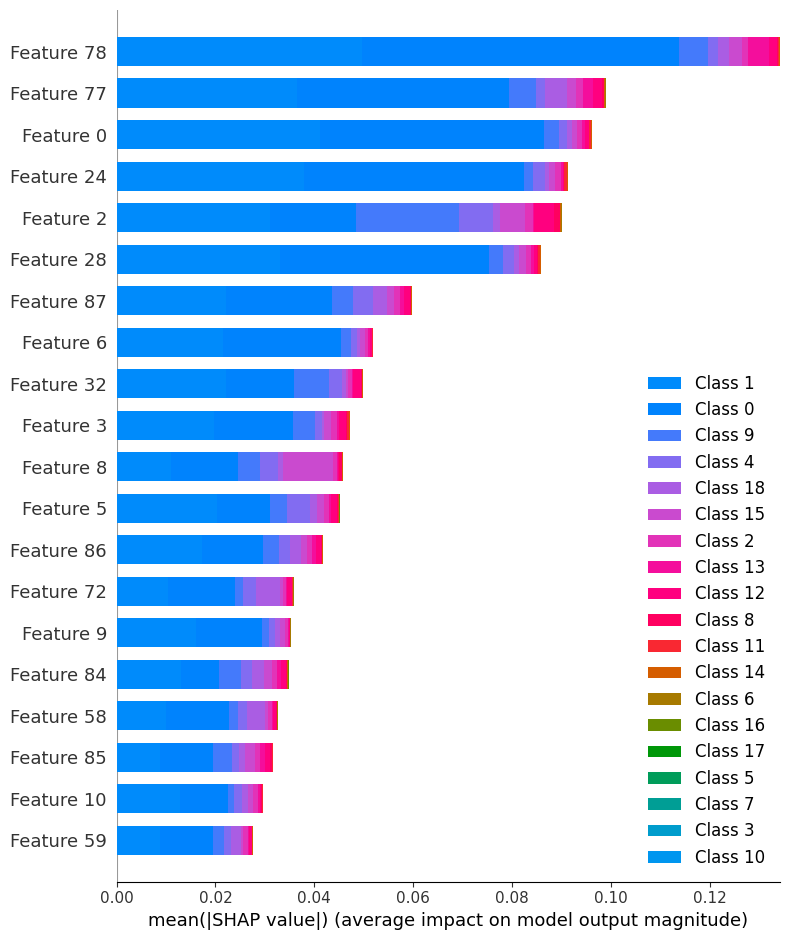

In [23]:
def predict_fn(X):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    if not isinstance(X, np.ndarray):
        X = X.values
    X_tensor = torch.tensor(X, dtype=torch.float32).to(device)
    with torch.no_grad():
        outputs = torch.softmax(model(X_tensor), dim=1)
    return outputs.cpu().numpy()
    
rng = np.random.default_rng(42)
X_sample = X.sample(1000, random_state=42).values
explainer = shap.Explainer(predict_fn, X_sample)
shap_values = explainer(X_sample)
shap.summary_plot(shap_values, X_sample, rng=rng)

In [27]:
print("Accuracy:", accuracy_score(y, y_pred))
print("Weighted F1:", f1_score(y, y_pred, average='weighted'))
print("Macro F1:", f1_score(y, y_pred, average='macro'))
print("ROC-AUC:", roc_auc_score(y, y_prob, multi_class="ovr", average="weighted"))

Accuracy: 0.7604861111111111
Weighted F1: 0.7317619829770613
Macro F1: 0.4923185631167703
ROC-AUC: 0.9884858876212522


In [28]:
print(classification_report(y, y_pred, target_names=le.classes_))

               precision    recall  f1-score   support

       BENIGN       1.00      1.00      1.00      7200
    DrDoS_DNS       0.21      0.04      0.07       400
   DrDoS_LDAP       0.00      0.00      0.00       400
  DrDoS_MSSQL       0.46      0.55      0.50       400
    DrDoS_NTP       0.98      1.00      0.99       400
DrDoS_NetBIOS       0.67      0.01      0.03       400
   DrDoS_SNMP       0.33      0.36      0.35       400
   DrDoS_SSDP       0.27      0.06      0.09       400
    DrDoS_UDP       0.28      0.83      0.41       400
         LDAP       0.27      0.74      0.40       400
        MSSQL       0.48      0.36      0.41       400
      NetBIOS       0.36      0.99      0.53       400
      Portmap       0.90      0.20      0.32       400
          Syn       1.00      0.99      1.00       400
         TFTP       0.92      0.98      0.95       400
          UDP       0.00      0.00      0.00       400
      UDP-lag       0.38      0.26      0.31       400
       UD

C:\Users\Aristophanies\AppData\Roaming\Python\Python310\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Aristophanies\AppData\Roaming\Python\Python310\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Aristophanies\AppData\Roaming\Python\Python310\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, mod